<a href="https://colab.research.google.com/github/niazfh/CIND820/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Key Dataset Attributes

import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/TMU/fraud_oracle.csv")

n_variables = df.shape[1]
n_observations = df.shape[0]

missing_cells = df.isna().sum().sum()
missing_pct = (missing_cells / (n_variables * n_observations)) * 100

duplicate_rows = df.duplicated().sum()
duplicate_pct = (duplicate_rows / n_observations) * 100

total_memory = df.memory_usage(deep=True).sum()
avg_record_size = total_memory / n_observations

# Variable types
numeric_vars = df.select_dtypes(include=["number"]).shape[1]
categorical_vars = df.select_dtypes(exclude=["number"]).shape[1]

# Print results
print("Dataset statistics")
print("------------------")
print(f"Number of variables: {n_variables}")
print(f"Number of observations: {n_observations}")
print(f"Missing cells: {missing_cells}")
print(f"Missing cells (%): {missing_pct:.1f}%")
print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate rows (%): {duplicate_pct:.1f}%")
print(f"Total size in memory: {total_memory / 1024:.1f} KiB")
print(f"Average record size in memory: {avg_record_size:.1f} B")

print("\nVariable types")
print("--------------")
print(f"Numeric: {numeric_vars}")
print(f"Categorical: {categorical_vars}")

Dataset statistics
------------------
Number of variables: 33
Number of observations: 15420
Missing cells: 0
Missing cells (%): 0.0%
Duplicate rows: 0
Duplicate rows (%): 0.0%
Total size in memory: 21533.1 KiB
Average record size in memory: 1430.0 B

Variable types
--------------
Numeric: 9
Categorical: 24


In [2]:
import numpy as np

# Inspect dataset
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

#Clean column names
df.columns = df.columns.str.strip()

#Check missing values
print("\nMissing values by column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())


#Define target variable
target = "FraudFound_P"

#Drop irrelevant / leakage-prone columns
drop_cols = ["PolicyNumber", "RepNumber", "NumberOfSuppliments"]

df_prepared = df.drop(columns=drop_cols)

print("\nShape after dropping selected columns:", df_prepared.shape)

#Separate features and target
X = df_prepared.drop(columns=[target])
y = df_prepared[target]

#Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

# 10. Optional: check class distribution
print("\nTarget variable distribution:")
print(y.value_counts())
print("\nTarget variable distribution (%):")
print(y.value_counts(normalize=True) * 100)



Shape of dataset: (15420, 33)

Column names:
['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']

First 5 rows:
  Month  WeekOfMonth  DayOfWeek    Make AccidentArea DayOfWeekClaimed  \
0   Dec            5  Wednesday   Honda        Urban          Tuesday   
1   Jan            3  Wednesday   Honda        Urban           Monday   
2   Oct            5     Friday   Honda        Urban         Thursday   
3   Jun            2   Saturday  Toyota        Rural           Friday   
4   Jan            5     Monday   Honda        Urba

In [3]:
#Exploratory Data Analysis

import matplotlib.pyplot as plt

# Use default matplotlib (no seaborn)
plt.rcParams["figure.figsize"] = (8, 5)

# Assuming X and y already created from Data Preparation
df_eda = pd.concat([X, y], axis=1)
target = "FraudFound_P"

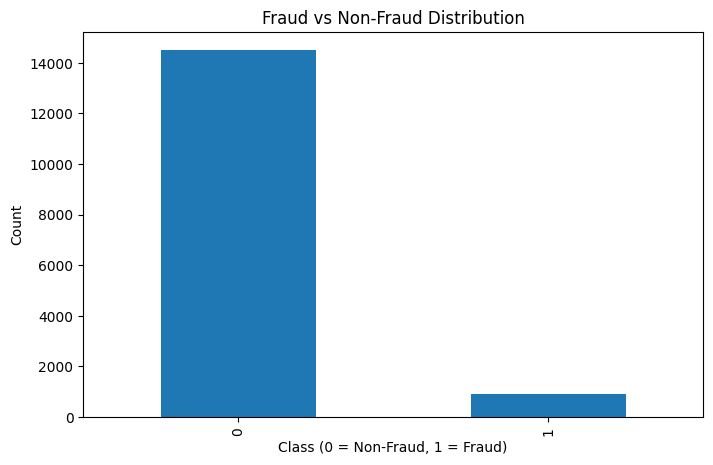

Class Distribution:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Percentage:
FraudFound_P
0    94.014267
1     5.985733
Name: count, dtype: float64


In [4]:
#Target Variable Distribution (Class Imbalance)
counts = df_eda[target].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

print("Class Distribution:")
print(counts)
print("\nPercentage:")
print(counts / len(df_eda) * 100)

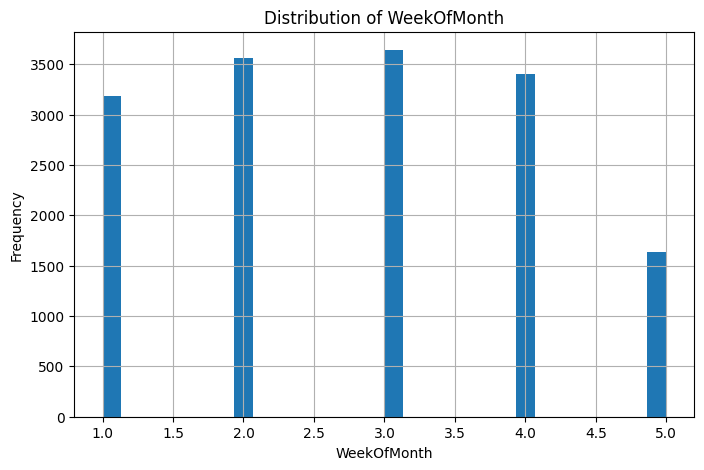

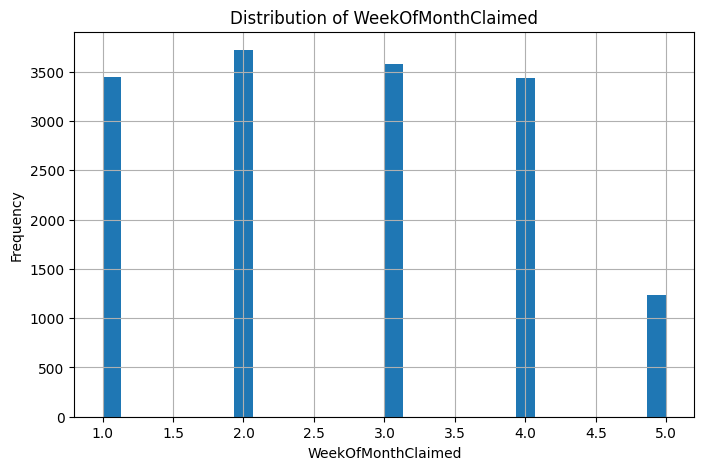

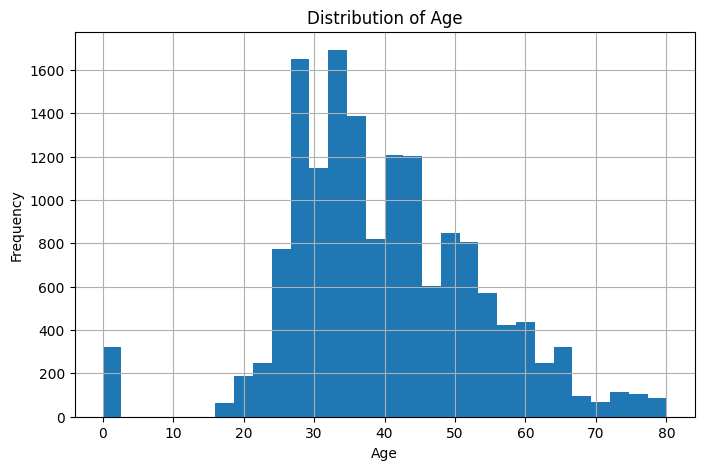

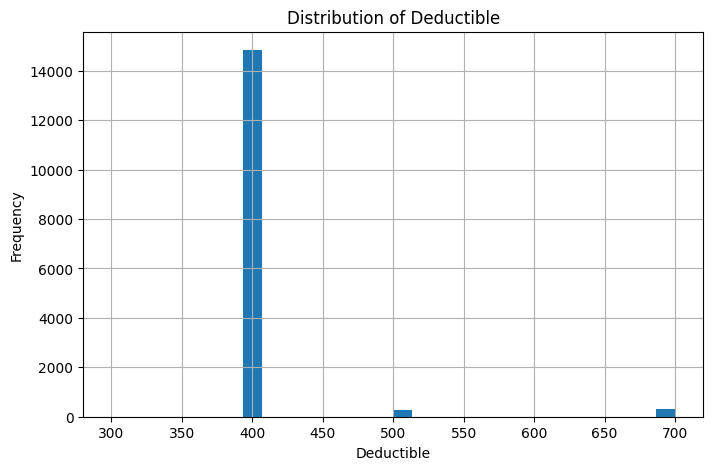

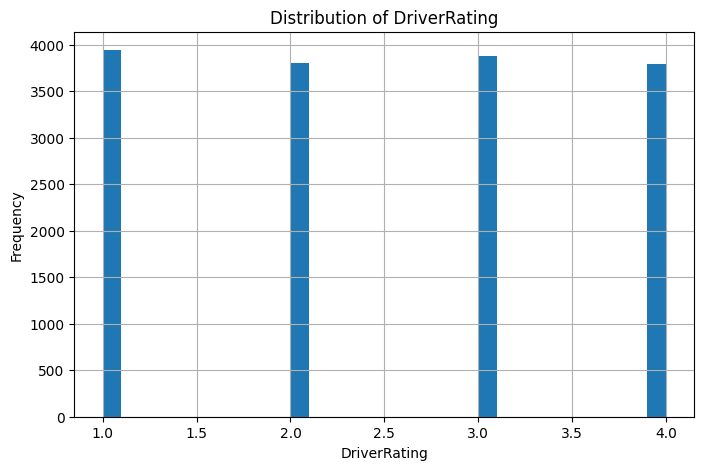

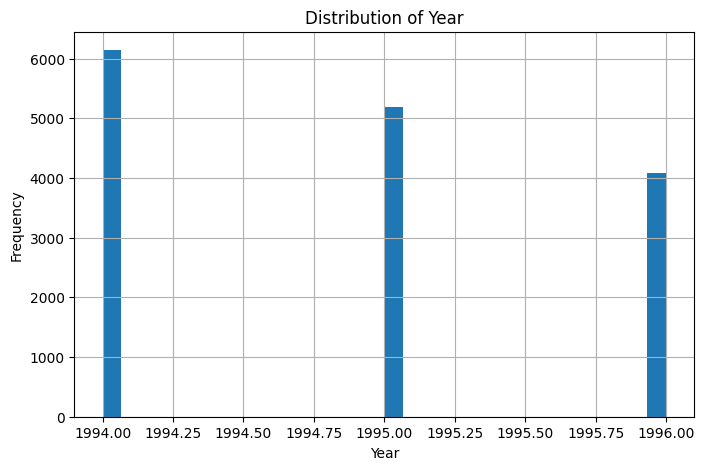

In [5]:
#Numerical Variables Distribution
num_cols = X.select_dtypes(exclude=["object"]).columns

for col in num_cols:
    plt.figure()
    df_eda[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

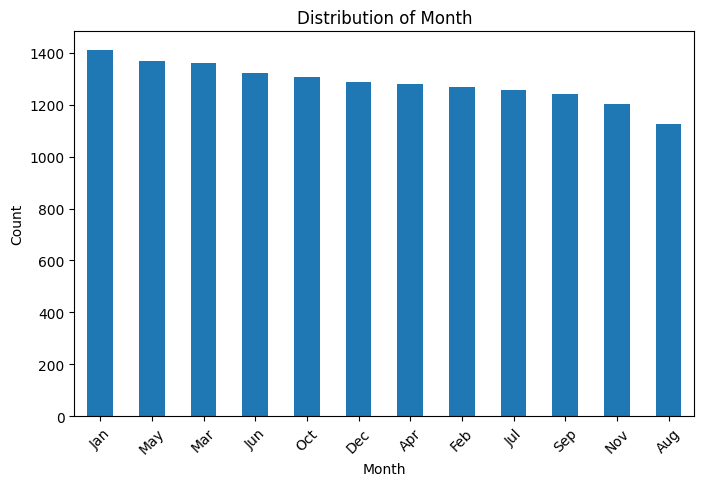

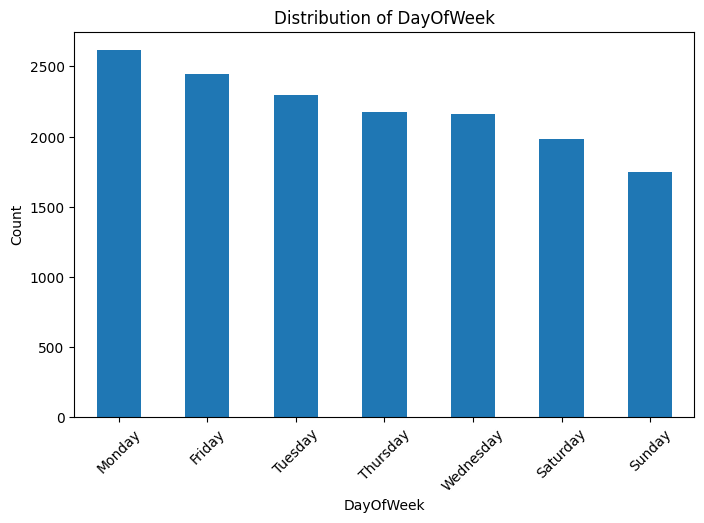

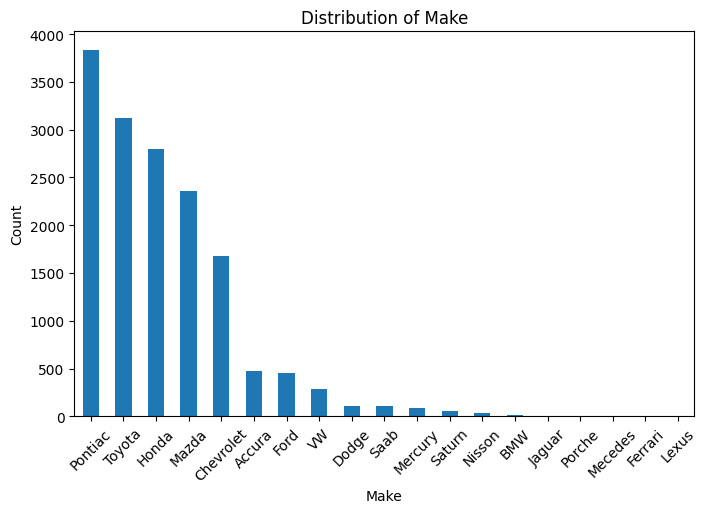

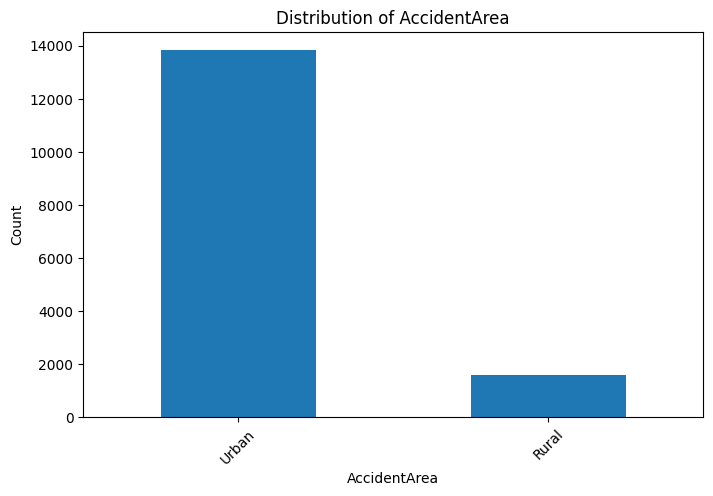

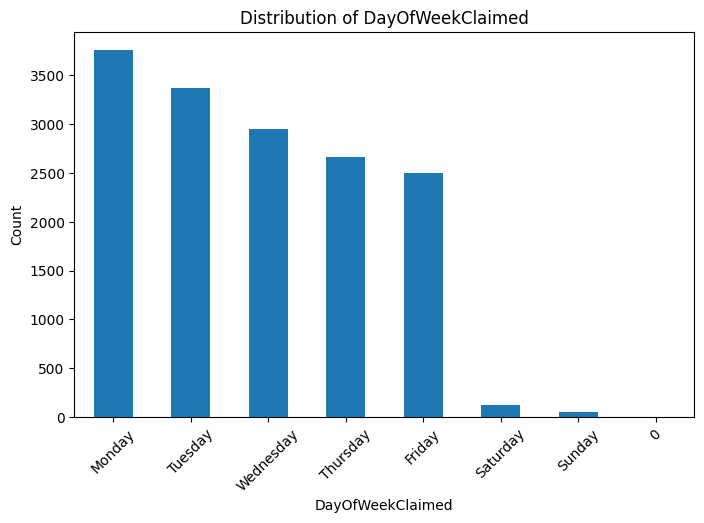

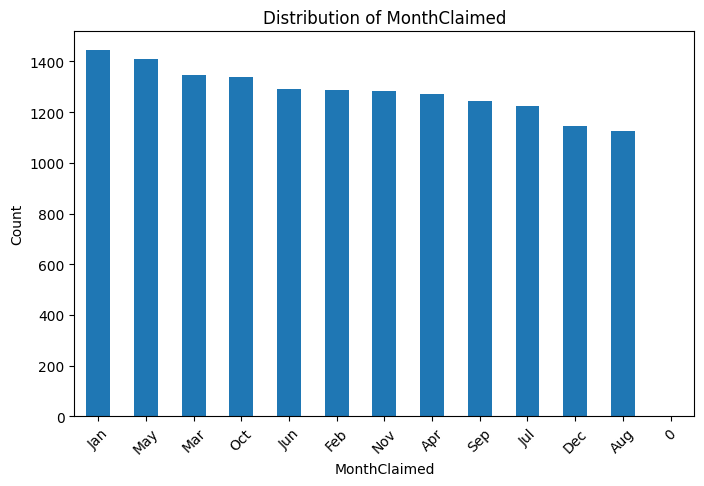

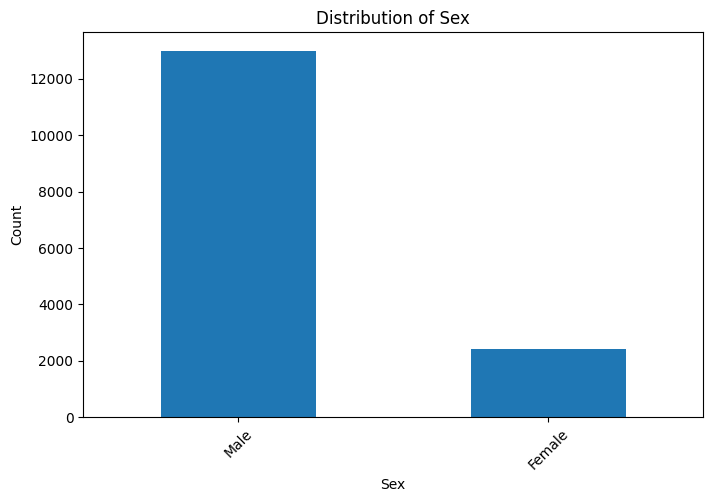

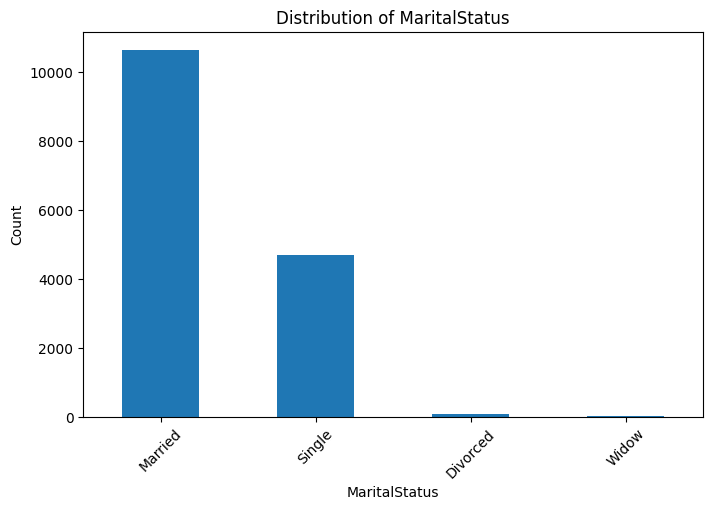

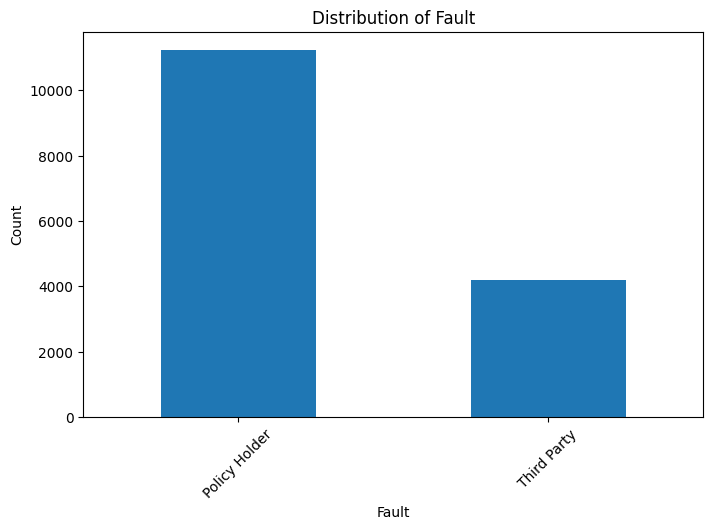

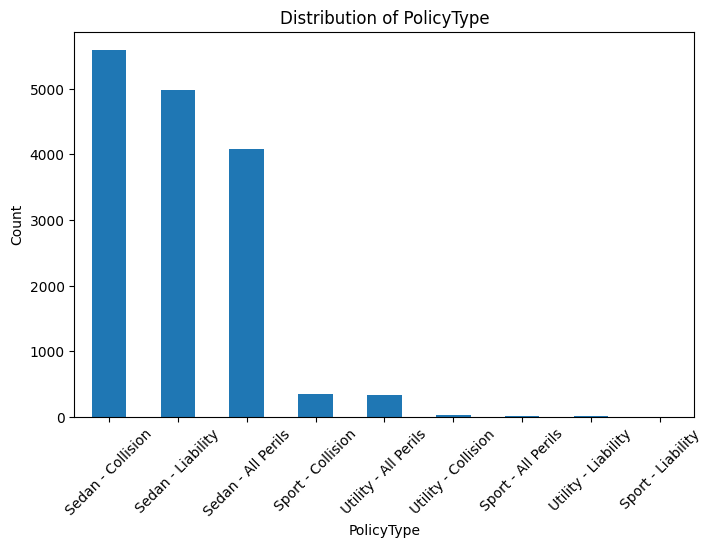

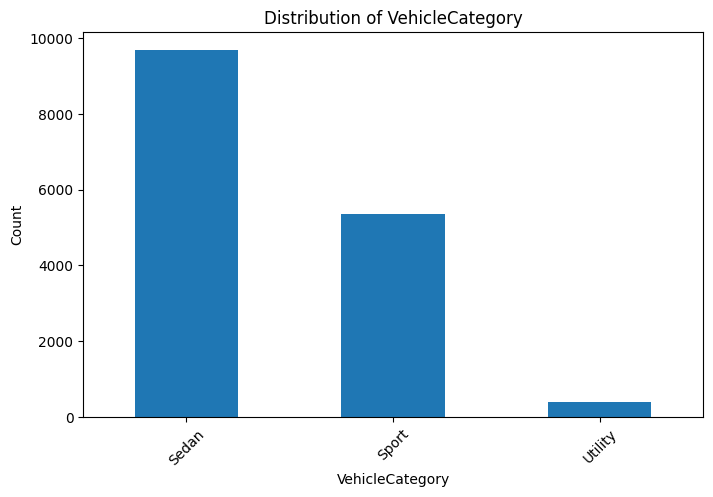

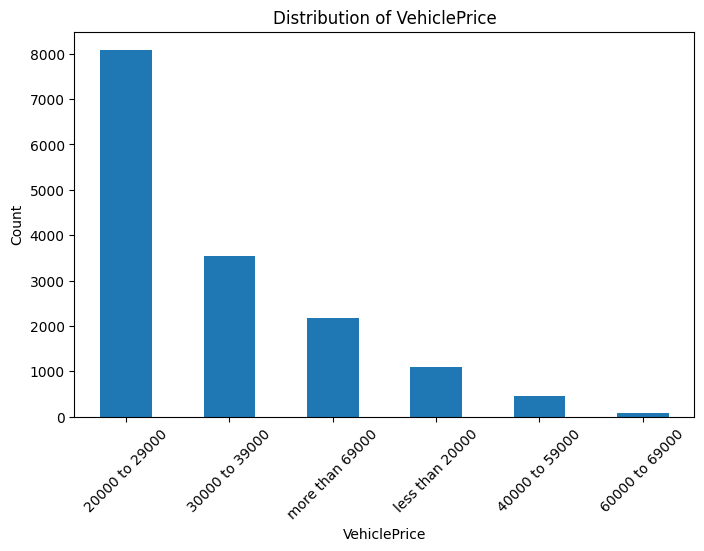

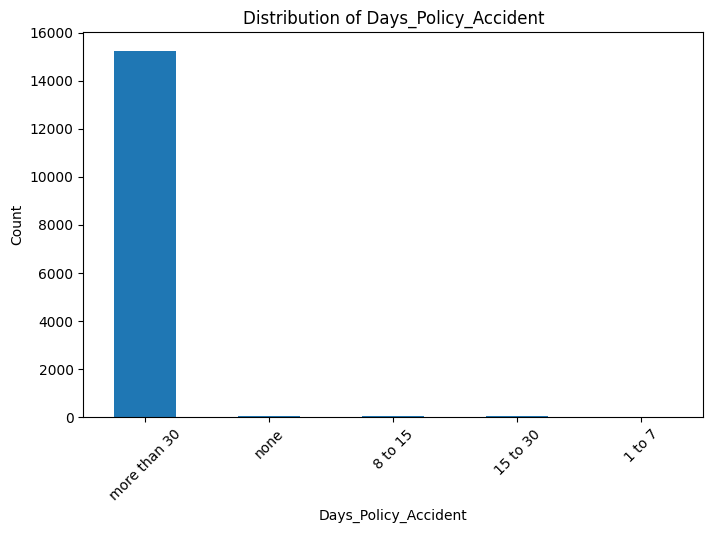

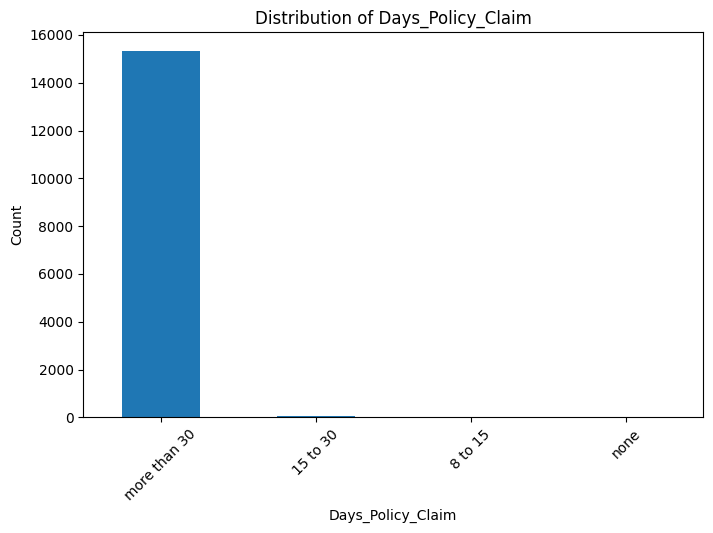

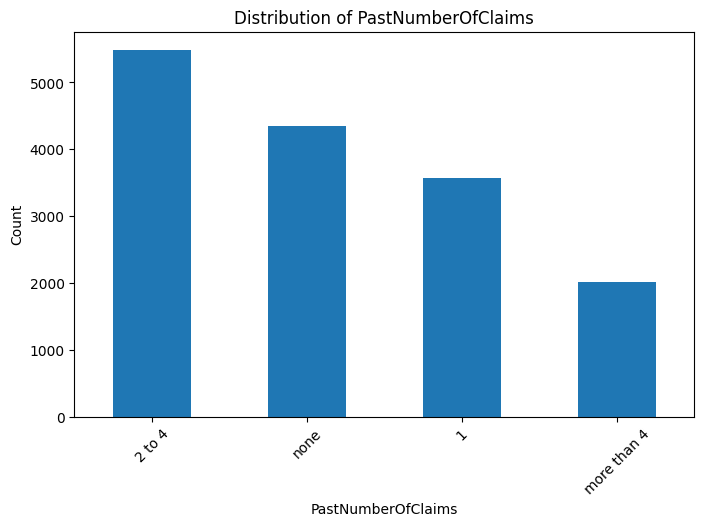

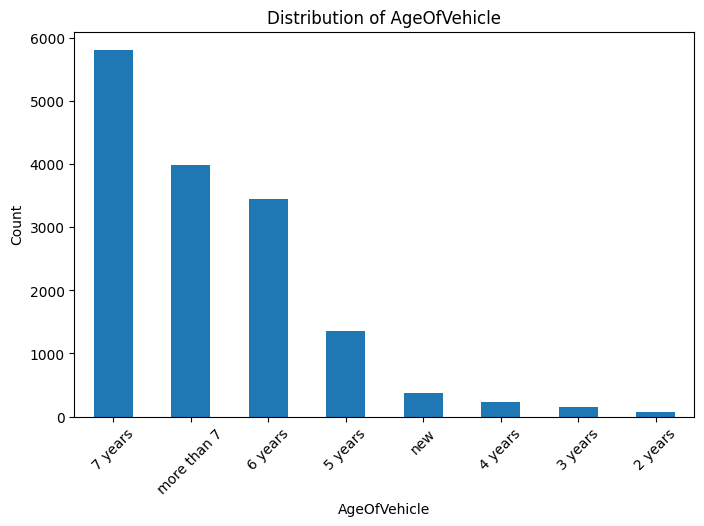

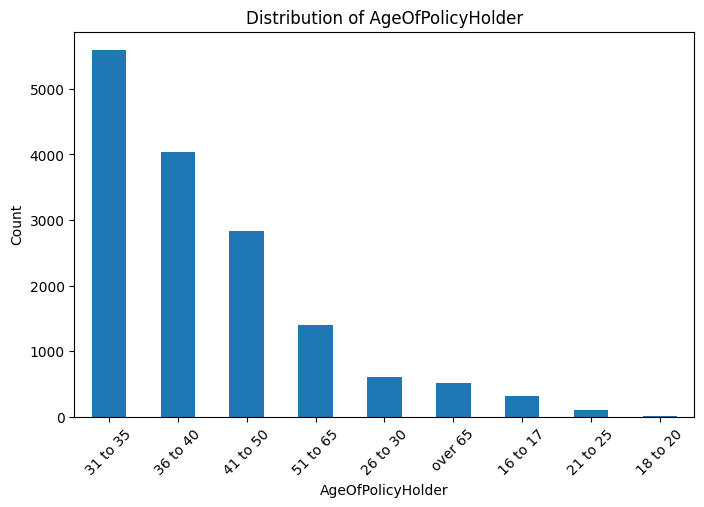

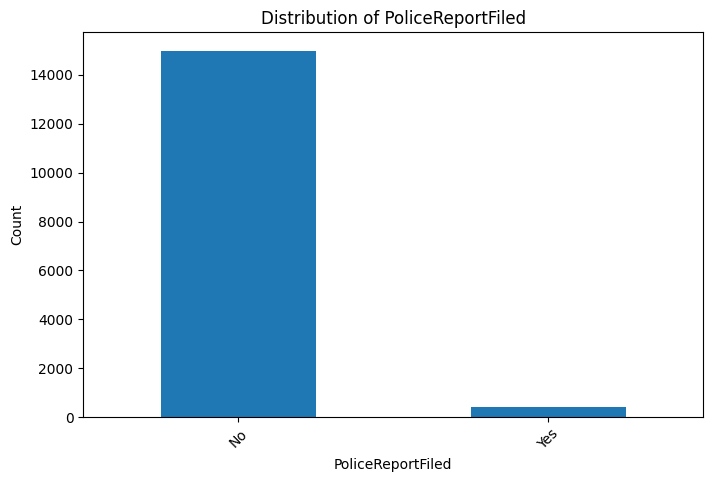

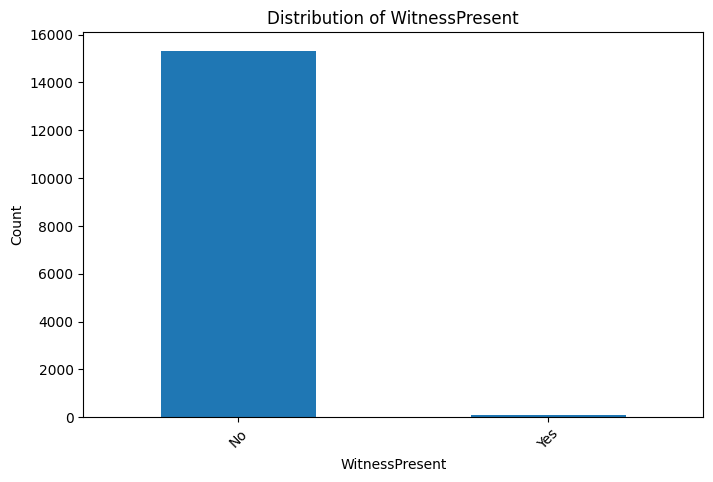

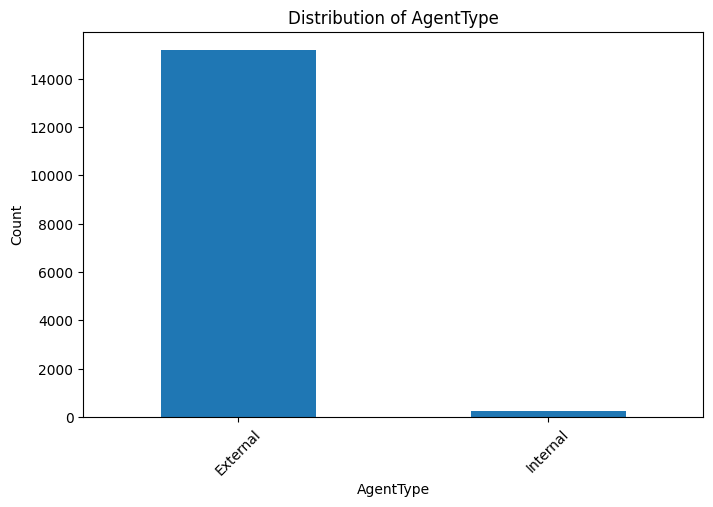

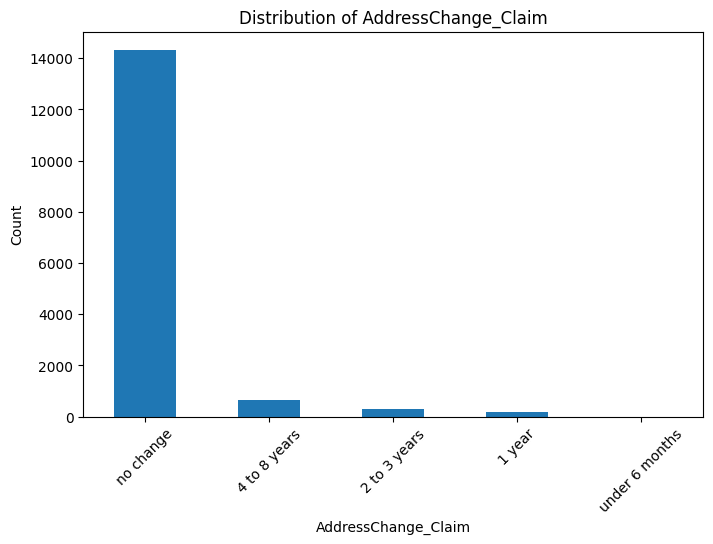

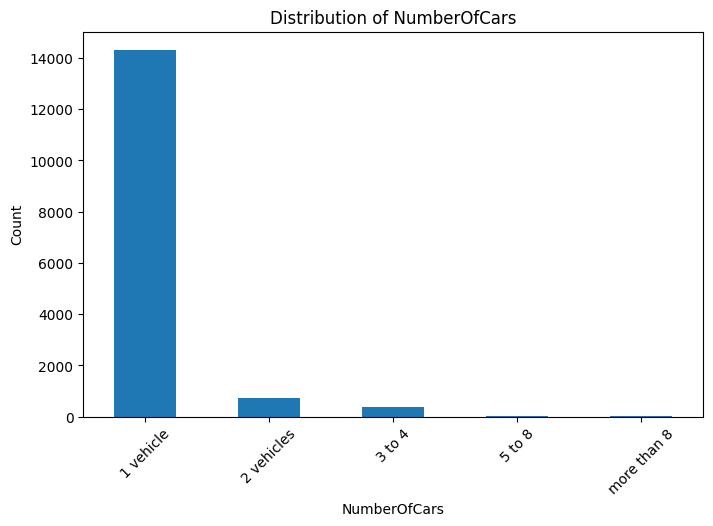

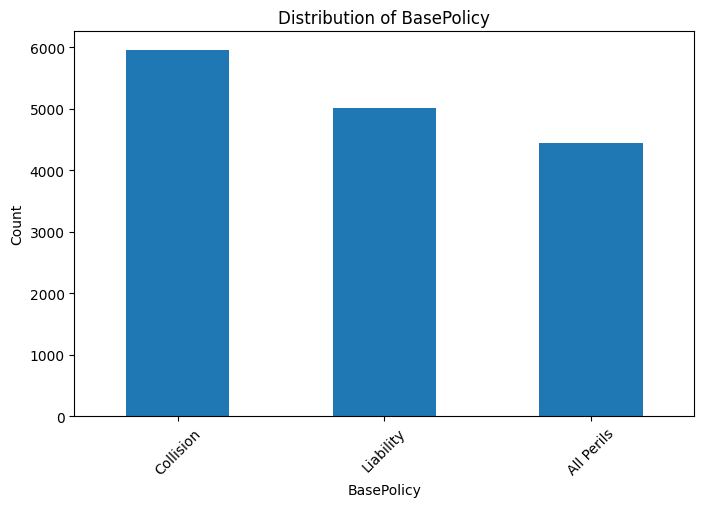

In [8]:
#Categorical Variables Distribution

cat_cols = X.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure()
    df_eda[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

<Figure size 800x500 with 0 Axes>

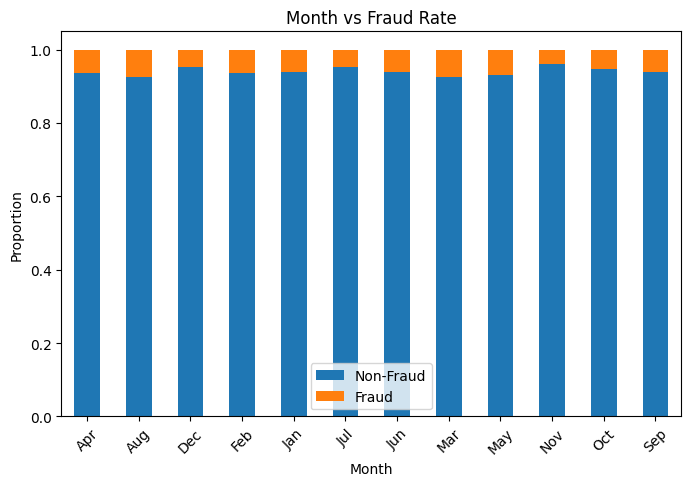

<Figure size 800x500 with 0 Axes>

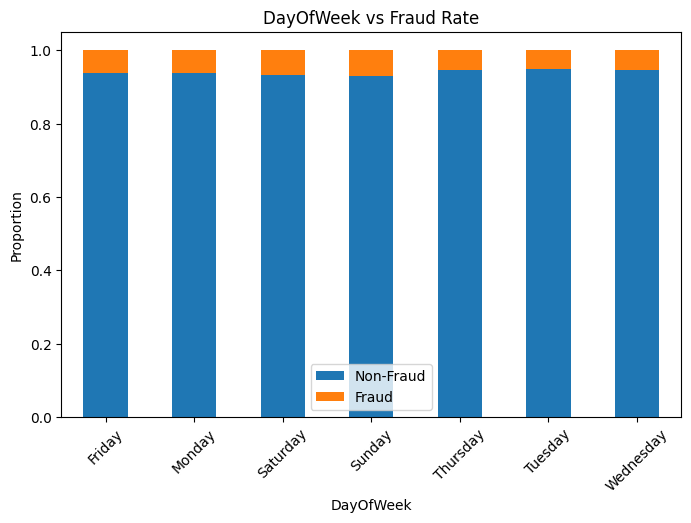

<Figure size 800x500 with 0 Axes>

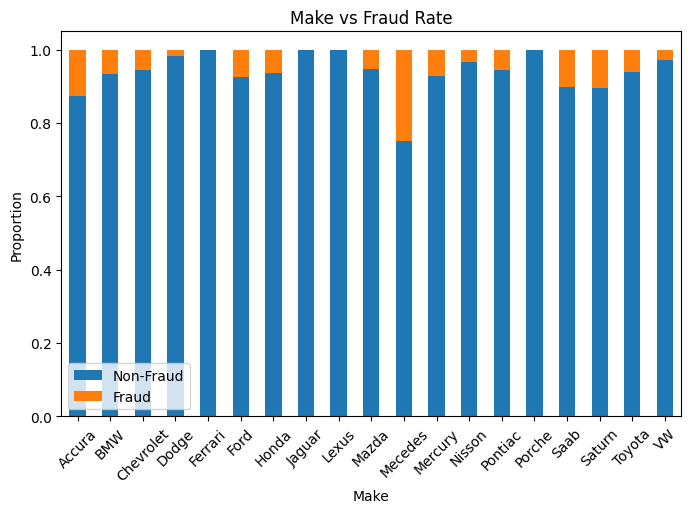

<Figure size 800x500 with 0 Axes>

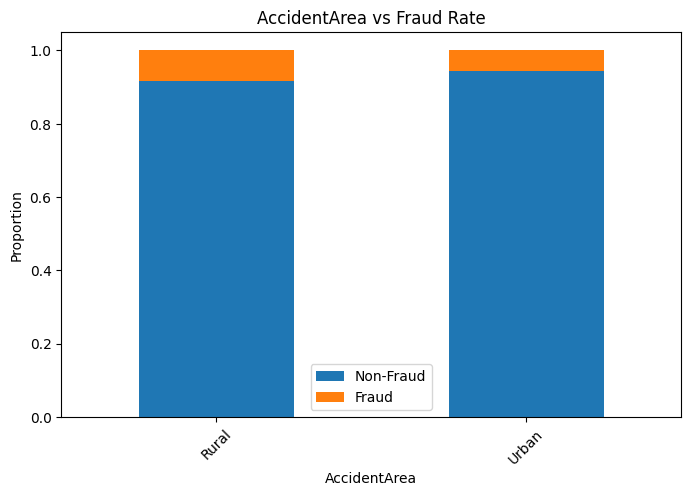

<Figure size 800x500 with 0 Axes>

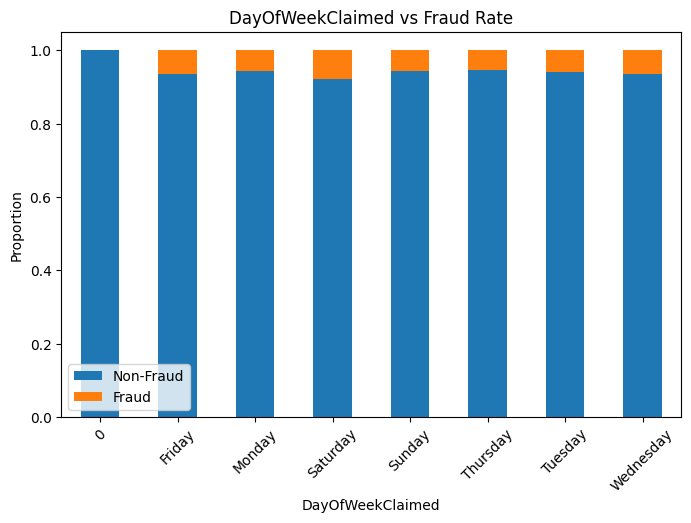

<Figure size 800x500 with 0 Axes>

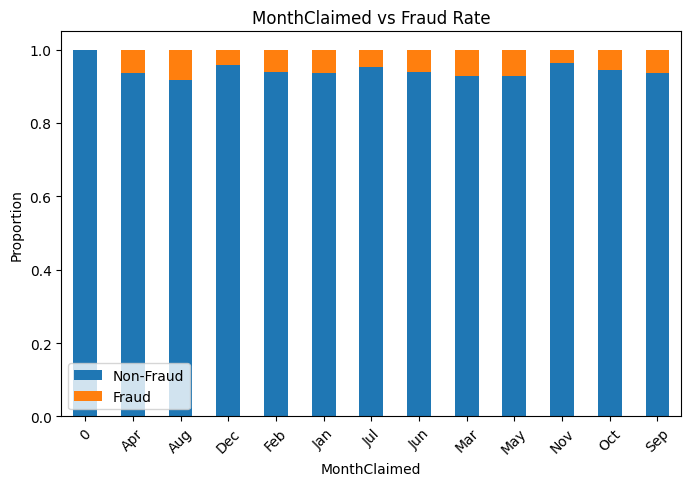

<Figure size 800x500 with 0 Axes>

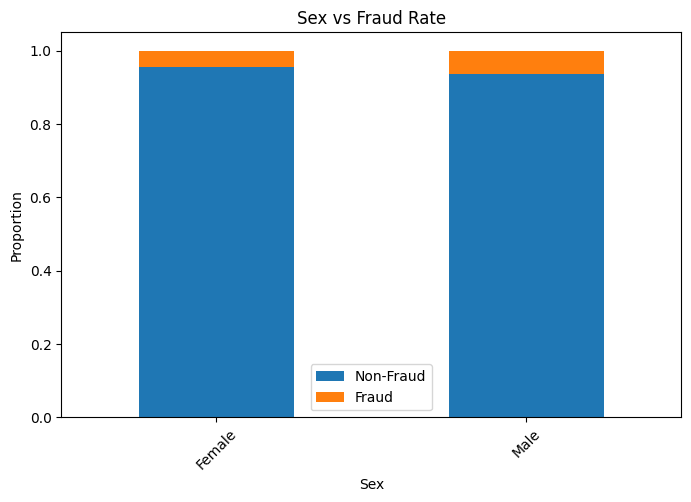

<Figure size 800x500 with 0 Axes>

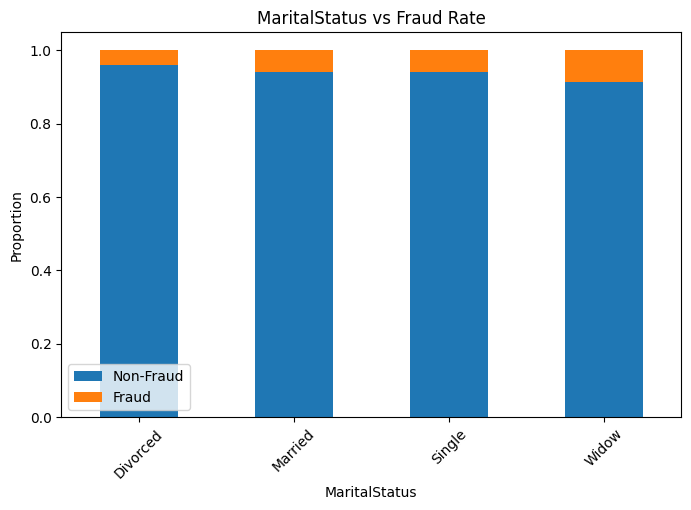

<Figure size 800x500 with 0 Axes>

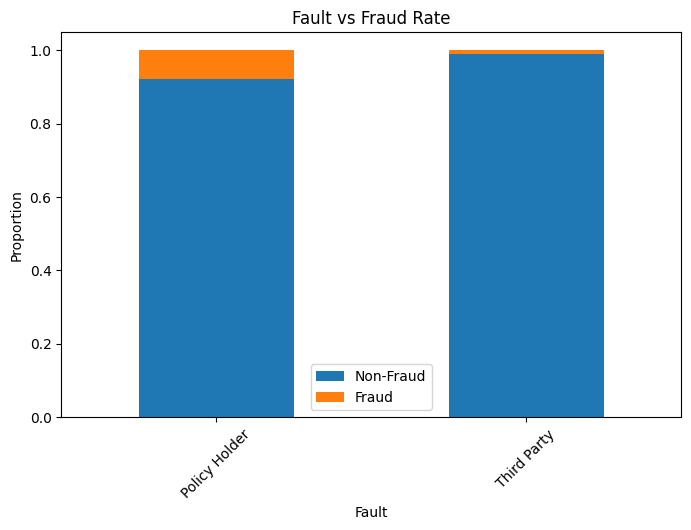

<Figure size 800x500 with 0 Axes>

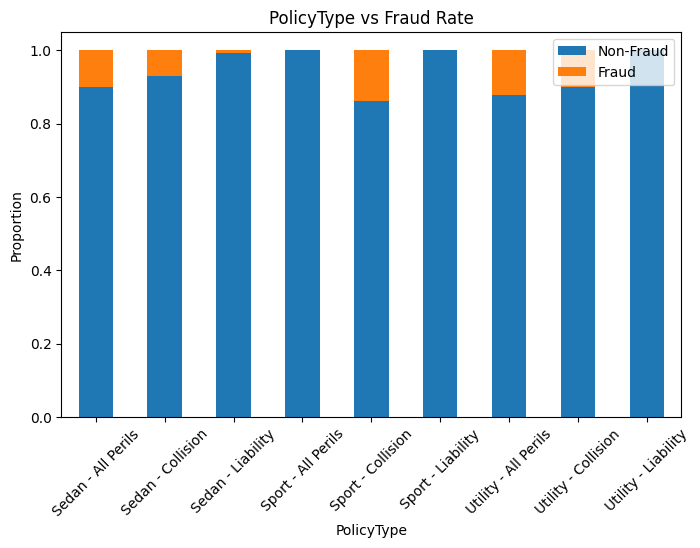

<Figure size 800x500 with 0 Axes>

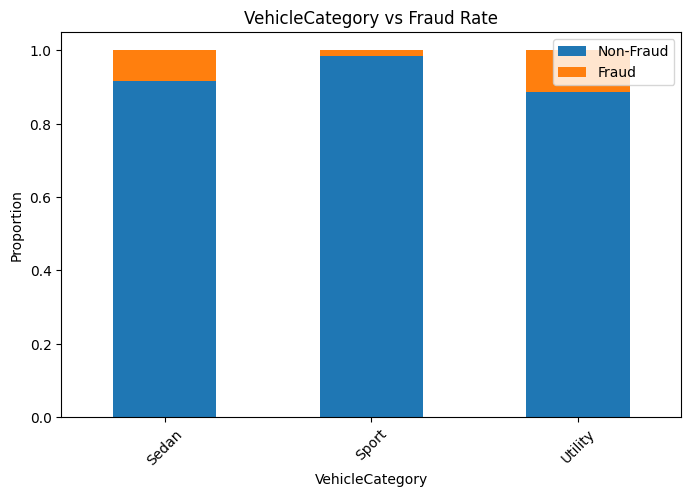

<Figure size 800x500 with 0 Axes>

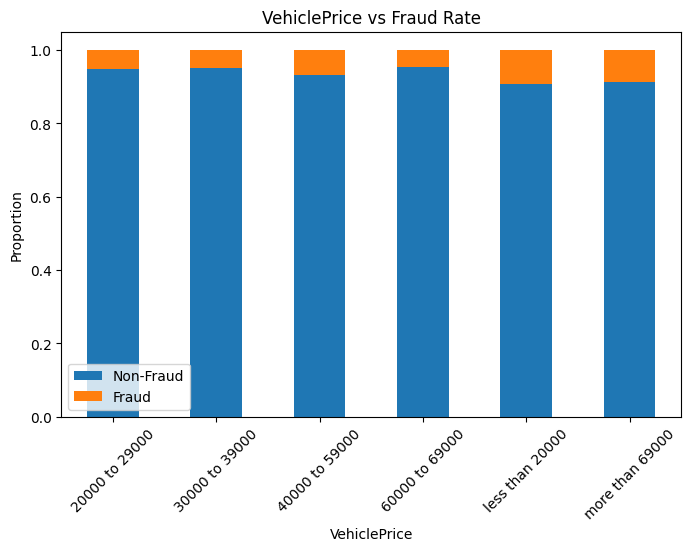

<Figure size 800x500 with 0 Axes>

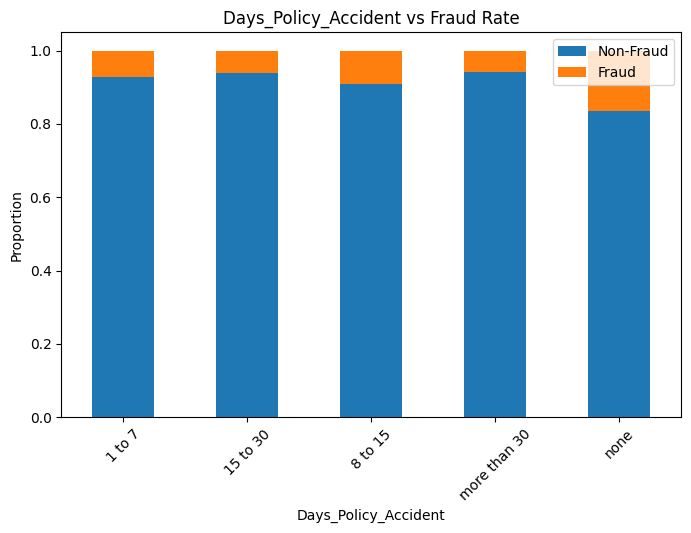

<Figure size 800x500 with 0 Axes>

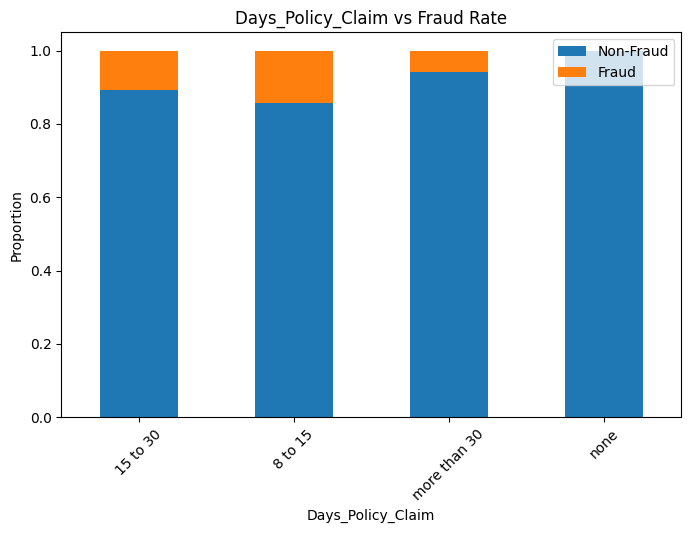

<Figure size 800x500 with 0 Axes>

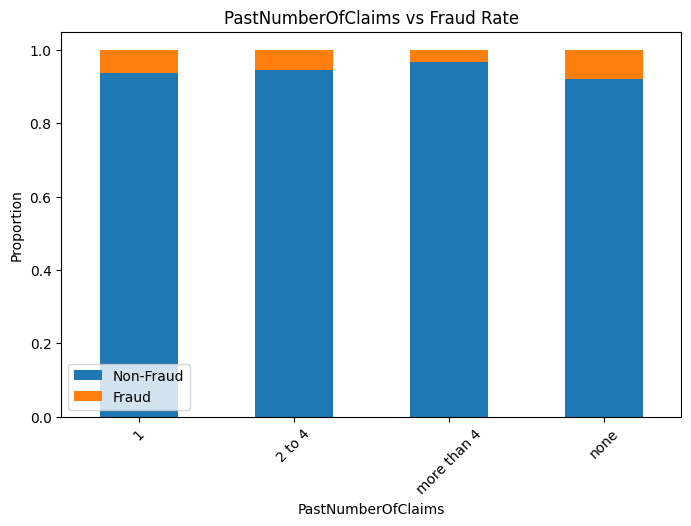

<Figure size 800x500 with 0 Axes>

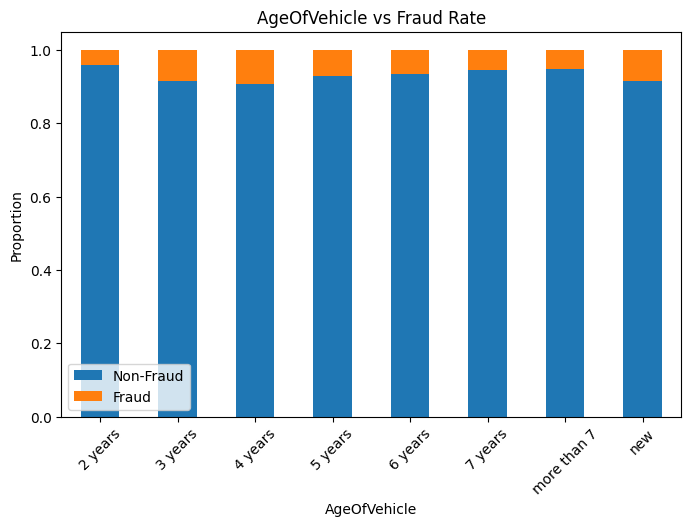

<Figure size 800x500 with 0 Axes>

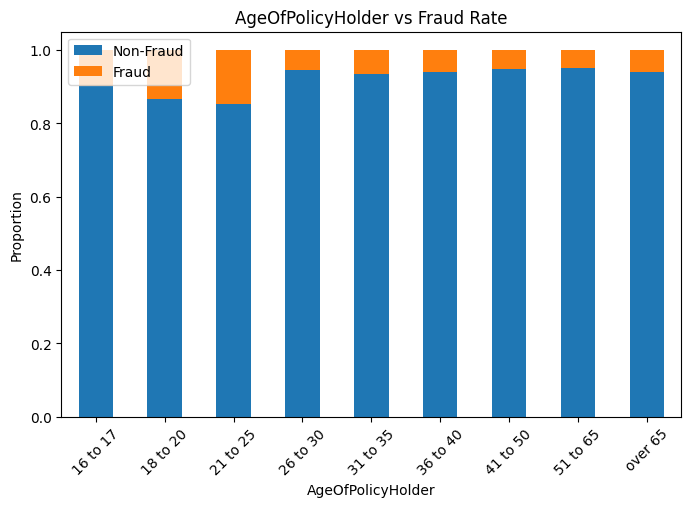

<Figure size 800x500 with 0 Axes>

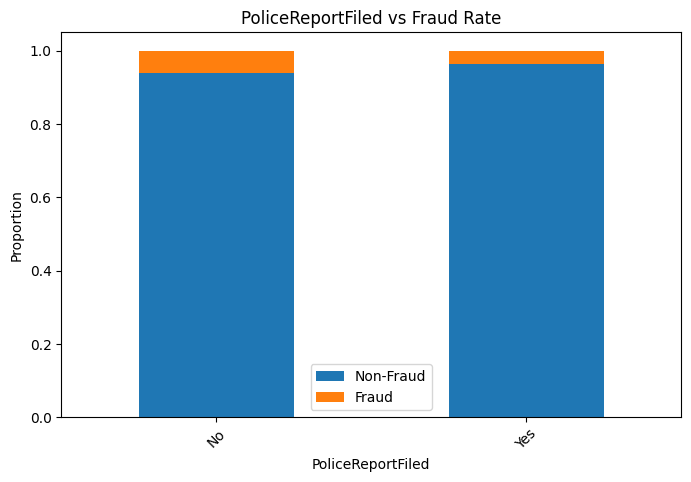

<Figure size 800x500 with 0 Axes>

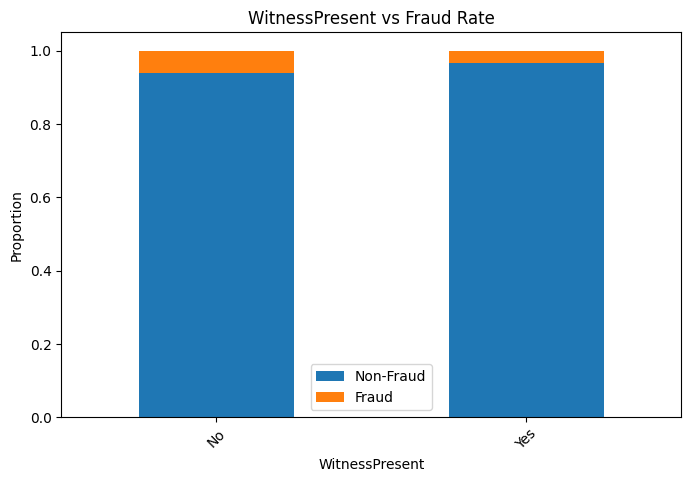

<Figure size 800x500 with 0 Axes>

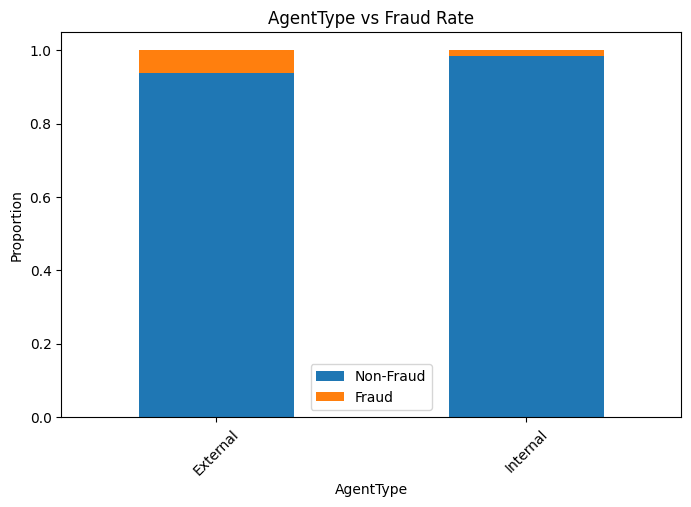

<Figure size 800x500 with 0 Axes>

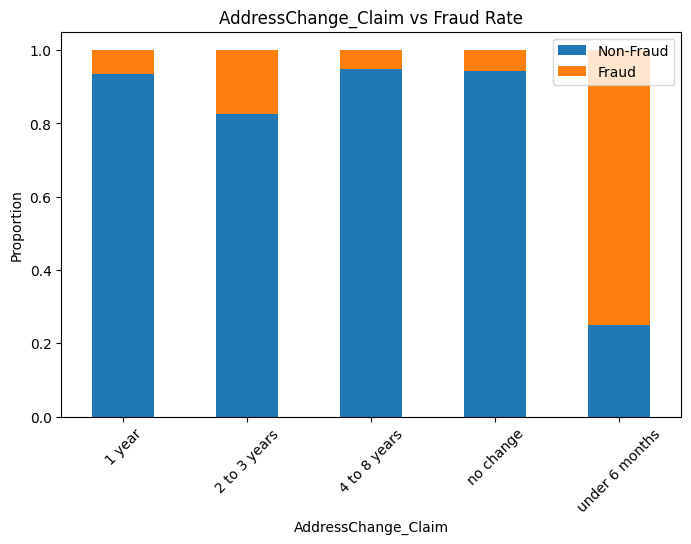

<Figure size 800x500 with 0 Axes>

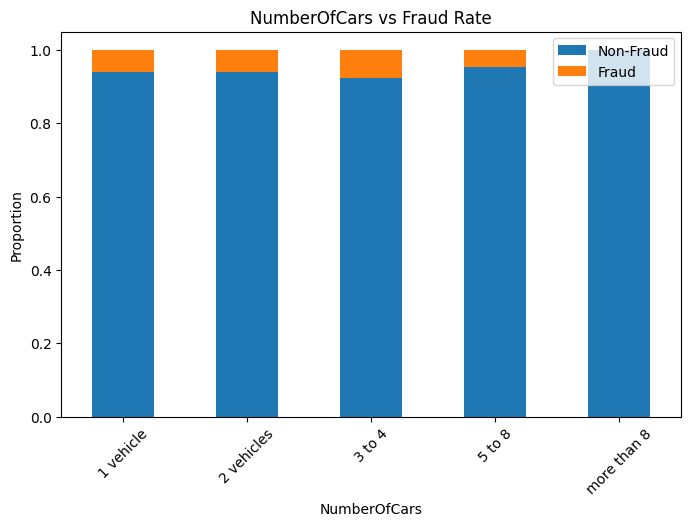

<Figure size 800x500 with 0 Axes>

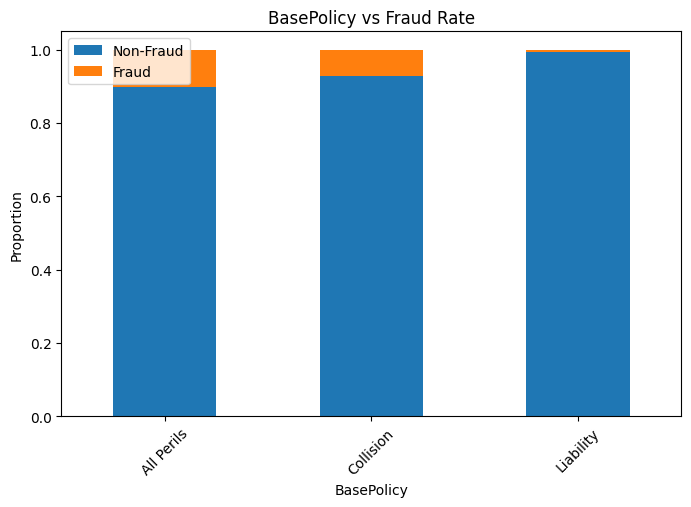

In [9]:
#Categorical Variables vs Fraud
for col in cat_cols:
    fraud_rate = pd.crosstab(df_eda[col], df_eda[target], normalize='index')

    plt.figure()
    fraud_rate.plot(kind="bar", stacked=True)
    plt.title(f"{col} vs Fraud Rate")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.legend(["Non-Fraud", "Fraud"])
    plt.xticks(rotation=45)
    plt.show()

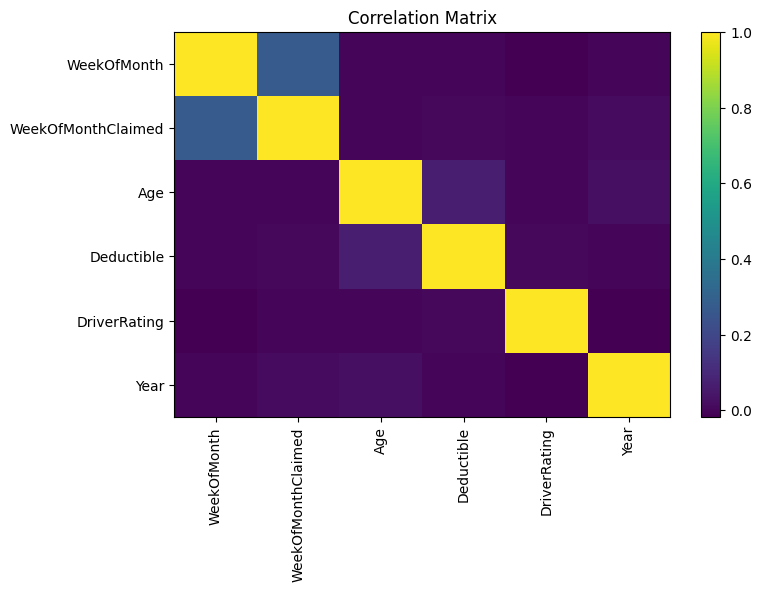

In [10]:
#Correlation Matrix

corr = df_eda[num_cols].corr()

plt.figure()
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Matrix")
plt.show()

In [11]:
#Fraud rate by key features

# Example: Fraud rate by Accident Area
fraud_by_area = pd.crosstab(df_eda["AccidentArea"], df_eda[target], normalize='index')
print("\nFraud Rate by Accident Area:")
print(fraud_by_area)

# Example: Fraud rate by Vehicle Category
fraud_by_vehicle = pd.crosstab(df_eda["VehicleCategory"], df_eda[target], normalize='index')
print("\nFraud Rate by Vehicle Category:")
print(fraud_by_vehicle)


Fraud Rate by Accident Area:
FraudFound_P         0         1
AccidentArea                    
Rural         0.916771  0.083229
Urban         0.942845  0.057155

Fraud Rate by Vehicle Category:
FraudFound_P            0         1
VehicleCategory                    
Sedan            0.917795  0.082205
Sport            0.984323  0.015677
Utility          0.887468  0.112532


In [12]:
#Data partitioning

from sklearn.model_selection import train_test_split

# Features (X) and target (y) already created from preprocessing

# Step 1: Train-Test Split (80% train, 20% test)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,       # preserves class imbalance
    random_state=42
)

# Step 2: Split training into Train + Validation (60/20/20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,   # 0.25 of 80% = 20%
    stratify=y_train_full,
    random_state=42
)

# Check sizes
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

# Check class distribution
print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Training set: (9252, 29)
Validation set: (3084, 29)
Test set: (3084, 29)

Train distribution:
FraudFound_P
0    0.940121
1    0.059879
Name: proportion, dtype: float64

Validation distribution:
FraudFound_P
0    0.940337
1    0.059663
Name: proportion, dtype: float64

Test distribution:
FraudFound_P
0    0.940013
1    0.059987
Name: proportion, dtype: float64


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),

        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols)
    ]
)

In [16]:
#Modeling
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# Preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())   # Added scaling for numeric features
            ]),
            num_cols
        )
    ]
)

# Logistic Regression model
lr_model = Pipeline([
    ("preprocess", preprocess),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

# Random Forest model
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1,
        min_samples_leaf=2
    ))
])

# Train models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Predicted probabilities for validation set
lr_val_prob = lr_model.predict_proba(X_val)[:, 1]
rf_val_prob = rf_model.predict_proba(X_val)[:, 1]

# Predicted probabilities for test set
lr_test_prob = lr_model.predict_proba(X_test)[:, 1]
rf_test_prob = rf_model.predict_proba(X_test)[:, 1]

print("Updated model training complete.")

Updated model training complete.


In [17]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [18]:
#Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    results = {
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "true_positive": tp,
        "false_positive": fp,
        "false_negative": fn,
        "true_negative": tn
    }

    return results

In [19]:
#Baseline Evaluation at Threshold = 0.50
lr_results_05 = evaluate_model(y_test, lr_test_prob, threshold=0.5)
rf_results_05 = evaluate_model(y_test, rf_test_prob, threshold=0.5)

print("Logistic Regression Results (Threshold = 0.50)")
print(lr_results_05)

print("\nRandom Forest Results (Threshold = 0.50)")
print(rf_results_05)

Logistic Regression Results (Threshold = 0.50)
{'threshold': 0.5, 'precision': 0.13246116107931316, 'recall': 0.8756756756756757, 'f1_score': 0.23011363636363635, 'roc_auc': np.float64(0.7993641796332379), 'pr_auc': np.float64(0.15538582451006108), 'true_positive': np.int64(162), 'false_positive': np.int64(1061), 'false_negative': np.int64(23), 'true_negative': np.int64(1838)}

Random Forest Results (Threshold = 0.50)
{'threshold': 0.5, 'precision': 0.47619047619047616, 'recall': 0.05405405405405406, 'f1_score': 0.0970873786407767, 'roc_auc': np.float64(0.8276572536662223), 'pr_auc': np.float64(0.2265424235475253), 'true_positive': np.int64(10), 'false_positive': np.int64(11), 'false_negative': np.int64(175), 'true_negative': np.int64(2888)}


In [20]:
#Classification Reports
lr_pred_05 = (lr_test_prob >= 0.5).astype(int)
rf_pred_05 = (rf_test_prob >= 0.5).astype(int)

print("Logistic Regression Classification Report")
print(classification_report(y_test, lr_pred_05, zero_division=0))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, rf_pred_05, zero_division=0))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.99      0.63      0.77      2899
           1       0.13      0.88      0.23       185

    accuracy                           0.65      3084
   macro avg       0.56      0.75      0.50      3084
weighted avg       0.94      0.65      0.74      3084


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.48      0.05      0.10       185

    accuracy                           0.94      3084
   macro avg       0.71      0.53      0.53      3084
weighted avg       0.91      0.94      0.92      3084



In [21]:
#Cost function

def cost_function(y_true, y_prob, threshold, cost_fp=100, cost_fn=1000):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    return total_cost

In [22]:
#Evaluate Different Thresholds on Validation Set

thresholds = np.arange(0.05, 0.95, 0.05)

lr_threshold_results = []
rf_threshold_results = []

for t in thresholds:
    lr_metrics = evaluate_model(y_val, lr_val_prob, threshold=t)
    rf_metrics = evaluate_model(y_val, rf_val_prob, threshold=t)

    lr_metrics["cost"] = cost_function(y_val, lr_val_prob, threshold=t, cost_fp=100, cost_fn=1000)
    rf_metrics["cost"] = cost_function(y_val, rf_val_prob, threshold=t, cost_fp=100, cost_fn=1000)

    lr_threshold_results.append(lr_metrics)
    rf_threshold_results.append(rf_metrics)

lr_threshold_df = pd.DataFrame(lr_threshold_results)
rf_threshold_df = pd.DataFrame(rf_threshold_results)

In [23]:
#Find Best Threshold
best_lr = lr_threshold_df.loc[lr_threshold_df["cost"].idxmin()]
best_rf = rf_threshold_df.loc[rf_threshold_df["cost"].idxmin()]

print("Best Logistic Regression Threshold:")
print(best_lr)

print("\nBest Random Forest Threshold:")
print(best_rf)


Best Logistic Regression Threshold:
threshold              0.600000
precision              0.149425
recall                 0.706522
f1_score               0.246679
roc_auc                0.797262
pr_auc                 0.151861
true_positive        130.000000
false_positive       740.000000
false_negative        54.000000
true_negative       2160.000000
cost              128000.000000
Name: 11, dtype: float64

Best Random Forest Threshold:
threshold              0.200000
precision              0.169536
recall                 0.695652
f1_score               0.272630
roc_auc                0.832491
pr_auc                 0.233343
true_positive        128.000000
false_positive       627.000000
false_negative        56.000000
true_negative       2273.000000
cost              118700.000000
Name: 3, dtype: float64


In [24]:
#Apply Best Threshold to Test Set

best_lr_threshold = best_lr["threshold"]
best_rf_threshold = best_rf["threshold"]

lr_best_results = evaluate_model(y_test, lr_test_prob, threshold=best_lr_threshold)
rf_best_results = evaluate_model(y_test, rf_test_prob, threshold=best_rf_threshold)

print("Optimized Logistic Regression Test Results")
print(lr_best_results)

print("\nOptimized Random Forest Test Results")
print(rf_best_results)

Optimized Logistic Regression Test Results
{'threshold': np.float64(0.6000000000000001), 'precision': 0.1396588486140725, 'recall': 0.7081081081081081, 'f1_score': 0.23330365093499555, 'roc_auc': np.float64(0.7993641796332379), 'pr_auc': np.float64(0.15538582451006108), 'true_positive': np.int64(131), 'false_positive': np.int64(807), 'false_negative': np.int64(54), 'true_negative': np.int64(2092)}

Optimized Random Forest Test Results
{'threshold': np.float64(0.2), 'precision': 0.15480649188514356, 'recall': 0.6702702702702703, 'f1_score': 0.2515212981744422, 'roc_auc': np.float64(0.8276572536662223), 'pr_auc': np.float64(0.2265424235475253), 'true_positive': np.int64(124), 'false_positive': np.int64(677), 'false_negative': np.int64(61), 'true_negative': np.int64(2222)}


In [25]:
#Top-K Recall / Lift

def top_k_recall(y_true, y_prob, top_percent=0.10):
    n = len(y_prob)
    k = int(n * top_percent)

    sorted_idx = np.argsort(y_prob)[::-1]
    top_idx = sorted_idx[:k]

    y_true_array = np.array(y_true)
    fraud_in_top_k = y_true_array[top_idx].sum()
    total_fraud = y_true_array.sum()

    recall_at_k = fraud_in_top_k / total_fraud
    precision_at_k = fraud_in_top_k / k
    base_rate = total_fraud / n
    lift = precision_at_k / base_rate

    return {
        "top_percent": top_percent,
        "claims_reviewed": k,
        "fraud_captured": int(fraud_in_top_k),
        "total_fraud": int(total_fraud),
        "recall_at_k": recall_at_k,
        "precision_at_k": precision_at_k,
        "lift": lift
    }

# Example using Random Forest
top_5 = top_k_recall(y_test, rf_test_prob, top_percent=0.05)
top_10 = top_k_recall(y_test, rf_test_prob, top_percent=0.10)
top_20 = top_k_recall(y_test, rf_test_prob, top_percent=0.20)

print("Top 5% Triage:", top_5)
print("Top 10% Triage:", top_10)
print("Top 20% Triage:", top_20)

Top 5% Triage: {'top_percent': 0.05, 'claims_reviewed': 154, 'fraud_captured': 39, 'total_fraud': 185, 'recall_at_k': np.float64(0.21081081081081082), 'precision_at_k': np.float64(0.2532467532467532), 'lift': np.float64(4.221691821691821)}
Top 10% Triage: {'top_percent': 0.1, 'claims_reviewed': 308, 'fraud_captured': 65, 'total_fraud': 185, 'recall_at_k': np.float64(0.35135135135135137), 'precision_at_k': np.float64(0.21103896103896103), 'lift': np.float64(3.518076518076518)}
Top 20% Triage: {'top_percent': 0.2, 'claims_reviewed': 616, 'fraud_captured': 112, 'total_fraud': 185, 'recall_at_k': np.float64(0.6054054054054054), 'precision_at_k': np.float64(0.18181818181818182), 'lift': np.float64(3.030958230958231)}


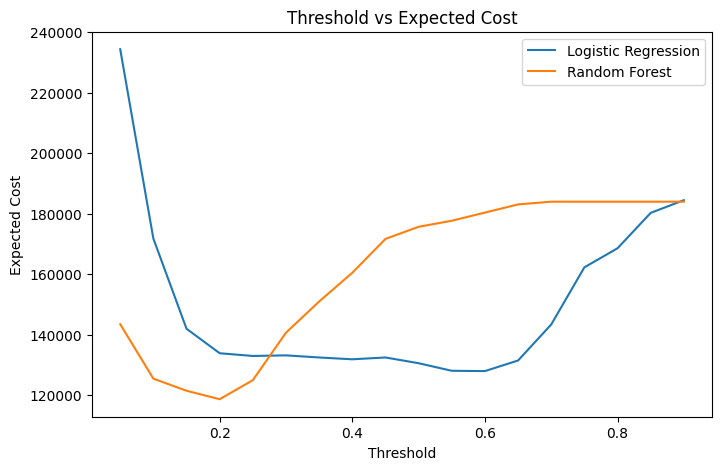

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(lr_threshold_df["threshold"], lr_threshold_df["cost"], label="Logistic Regression")
plt.plot(rf_threshold_df["threshold"], rf_threshold_df["cost"], label="Random Forest")
plt.xlabel("Threshold")
plt.ylabel("Expected Cost")
plt.title("Threshold vs Expected Cost")
plt.legend()
plt.show()

In [27]:
results = []

models = {
    "Logistic Regression": lr_test_prob,
    "Random Forest": rf_test_prob
}

for name, probs in models.items():
    preds = (probs >= 0.5).astype(int)

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc = roc_auc_score(y_test, probs)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression   0.132461  0.875676  0.230114  0.799364
1        Random Forest   0.476190  0.054054  0.097087  0.827657
